# Aula 03- Inferência Estatística com R

**Disciplina:** R para Ciência de Dados

**Professor:** Sérgio Monteiro, D.Sc.

**Pós-Graduação em Ciência de Dados**



# **Exemplo 1: Estimador Não-Viesado**

**Enunciado:**
Considere a população {1, 3, 6, 8}. Liste todas as amostras possíveis de tamanho n=2 com reposição e verifique se a média amostral x̄ é um estimador não-viesado de μ.

[1] 4.5

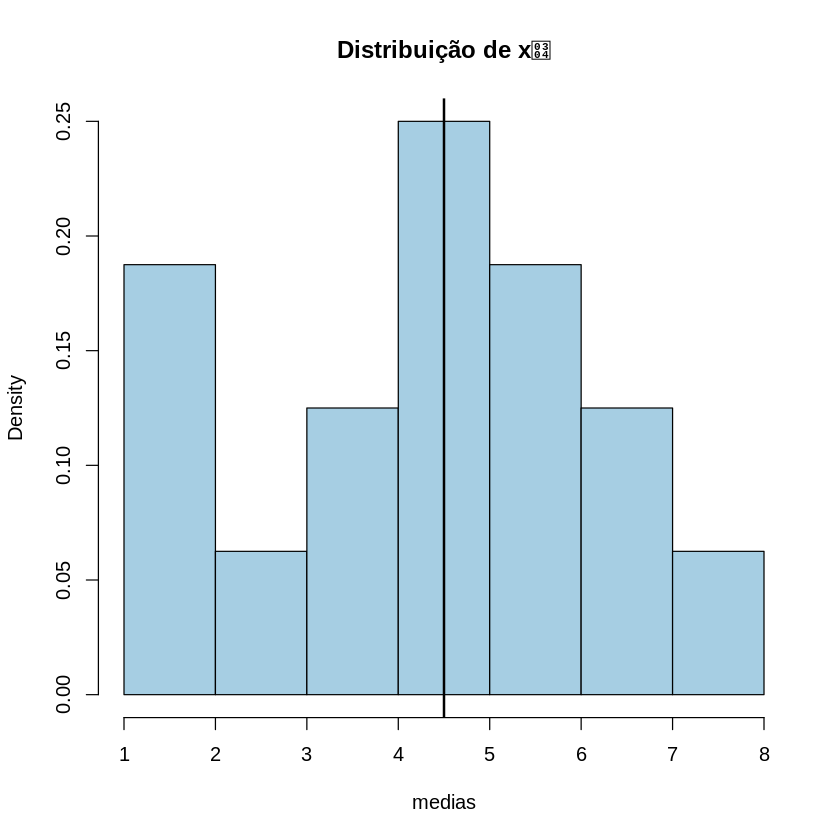

In [ ]:
pop <- c(1,3,6,8)
mu <- mean(pop)

amostras <- expand.grid(pop,pop)
medias <- apply(amostras,1,mean)

mean(medias)

hist(medias, probability=TRUE, col="#a6cee3",
     main="Distribuição de x̄")
abline(v=mu,lwd=2)

# **Exemplo 2: Distribuição Amostral (Simulação)**

**Enunciado:**
Simule 10.000 amostras de tamanho n=2 da população {1,3,6,8} e analise a distribuição da média amostral.

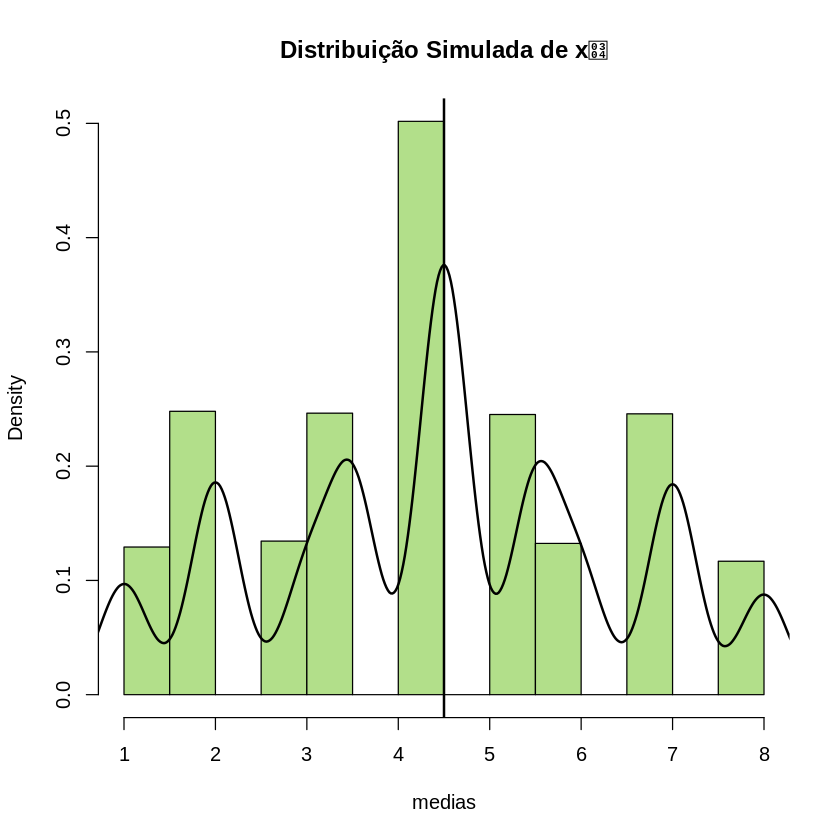

In [ ]:
set.seed(123)
medias <- replicate(10000, mean(sample(pop,2,replace=TRUE)))

hist(medias, probability=TRUE, col="#b2df8a",
     main="Distribuição Simulada de x̄")
lines(density(medias),lwd=2)
abline(v=mean(pop),lwd=2)

# **Exemplo 3: População vs Amostra**

**Enunciado:**
Compare visualmente a distribuição da população com a distribuição das médias amostrais.

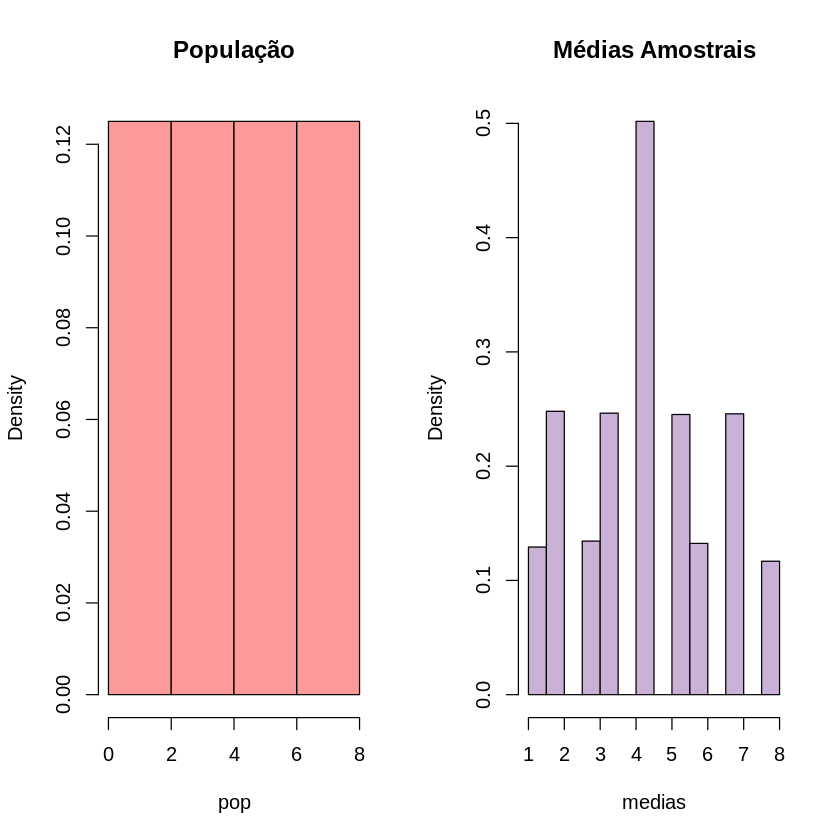

In [ ]:
par(mfrow=c(1,2))

hist(pop, probability=TRUE, col="#fb9a99",
     main="População")
hist(medias, probability=TRUE, col="#cab2d6",
     main="Médias Amostrais")

# **Exemplo 4: Variabilidade entre Amostras**

**Enunciado:**
Extraia duas amostras aleatórias da população e compare sua variabilidade.

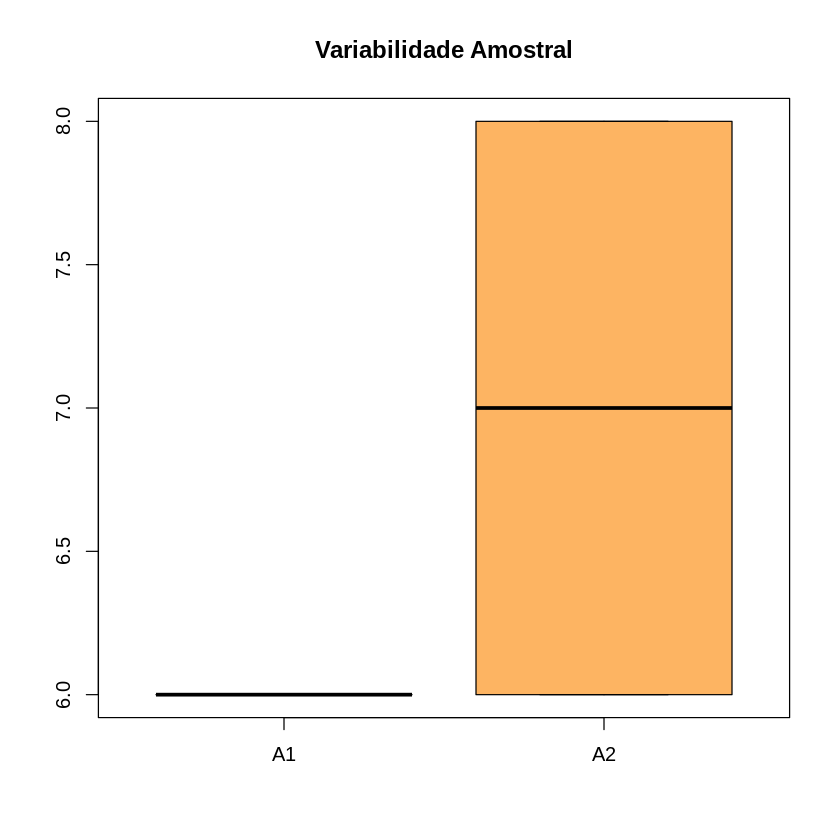

In [ ]:
a1 <- sample(pop,2,replace=TRUE)
a2 <- sample(pop,2,replace=TRUE)

boxplot(a1,a2, names=c("A1","A2"),
        col=c("#80b1d3","#fdb462"),
        main="Variabilidade Amostral")

# **Exemplo 5: Distribuição das Médias**

**Enunciado:**
Simule várias médias amostrais e observe sua distribuição.

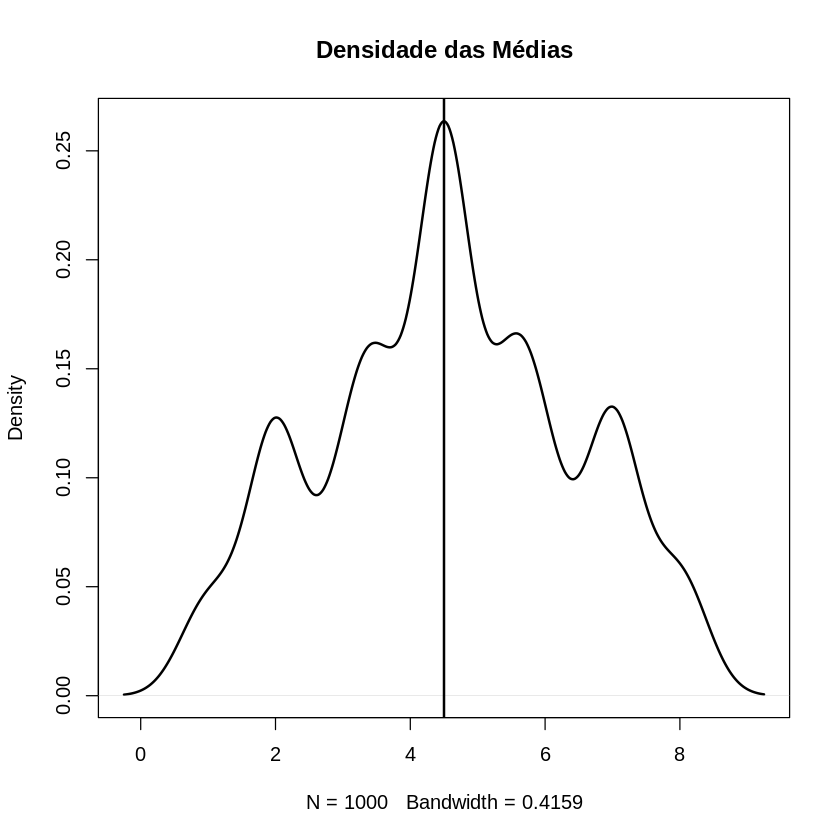

In [ ]:
medias <- replicate(1000, mean(sample(pop,2,replace=TRUE)))

plot(density(medias),lwd=2,
     main="Densidade das Médias")
abline(v=mean(pop),lwd=2)

# **Exemplo 6: Variância da Média**

**Enunciado:**
Compare a variância da média amostral com o valor teórico σ²/n.

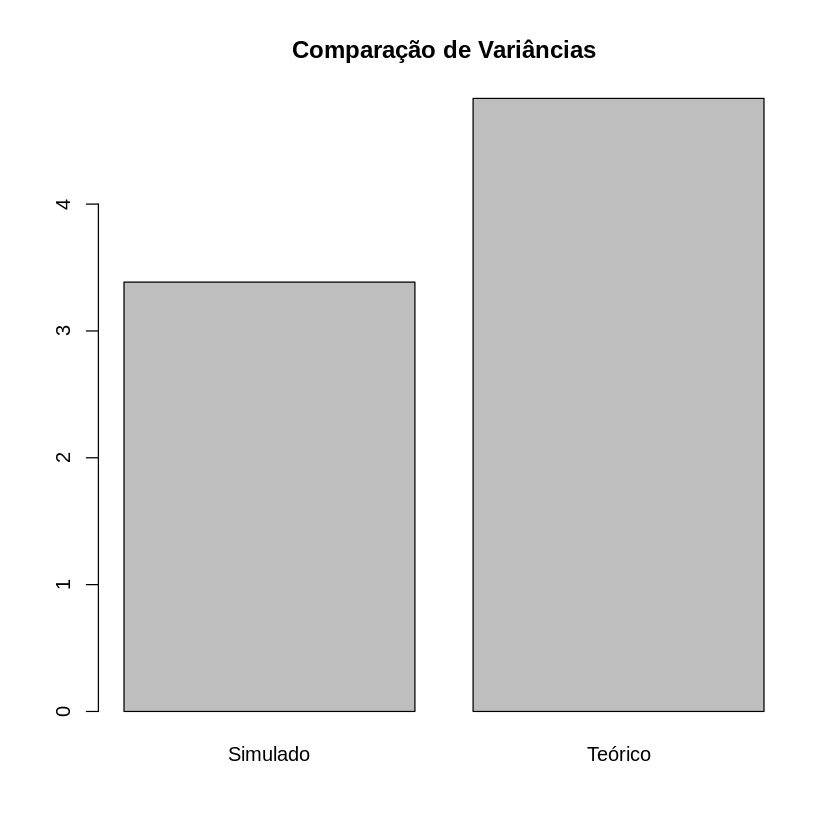

In [ ]:
barplot(c(var(medias), var(pop)/2),
        names.arg=c("Simulado","Teórico"),
        main="Comparação de Variâncias")

# **Exemplo 7: Distribuição de x̄ Normal**

**Enunciado:**
Considere uma população N(100,10). Visualize a distribuição de x̄ para n=16.

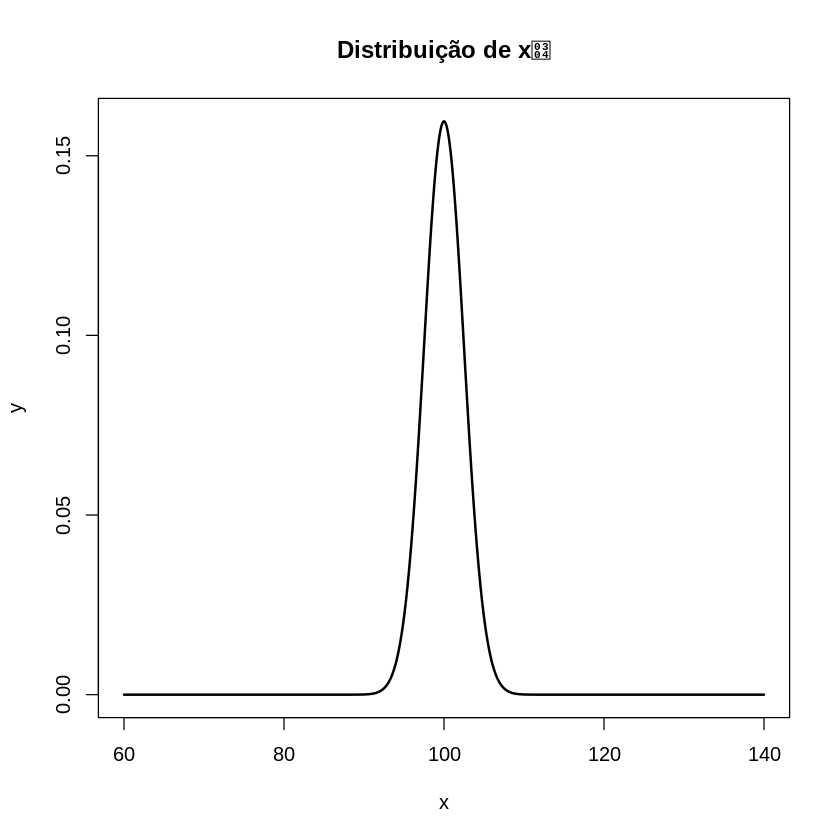

In [ ]:
x <- seq(60,140,0.1)
y <- dnorm(x,100,10/sqrt(16))

plot(x,y,type="l",lwd=2,
     main="Distribuição de x̄")

# **Exemplo 8: Probabilidade em Intervalo**

**Enunciado:**
Calcule graficamente a probabilidade de 90 < x̄ < 110.

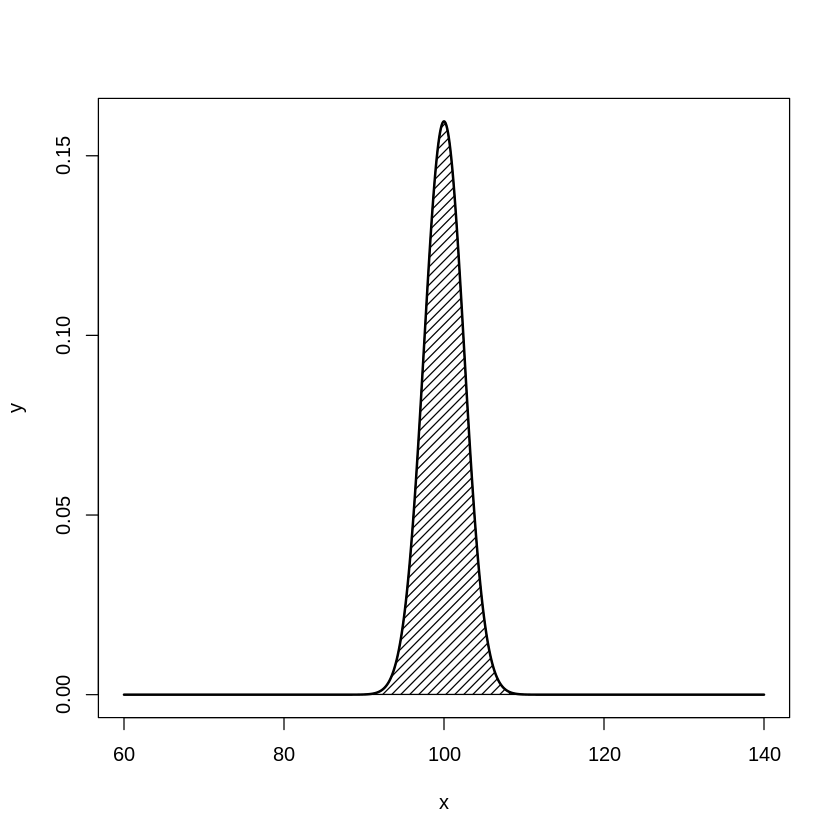

In [ ]:
plot(x,y,type="l",lwd=2)
polygon(c(x[x>90 & x<110]),
        y[x>90 & x<110], density=20)

# **Exemplo 9: Intervalo de Confiança**

**Enunciado:**
Construa o intervalo de confiança para μ com x̄=30, σ=5 e n=36.

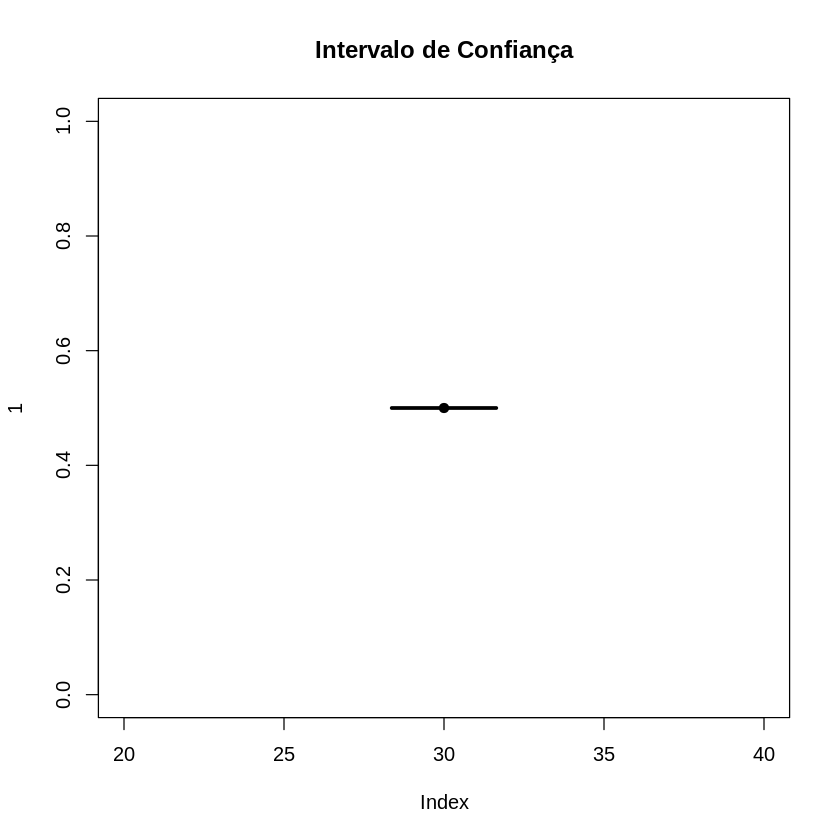

In [ ]:
xbar <- 30
erro <- qnorm(0.975)*5/sqrt(36)

plot(1,type="n",xlim=c(20,40),ylim=c(0,1),
     main="Intervalo de Confiança")
segments(xbar-erro,0.5,xbar+erro,0.5,lwd=3)
points(xbar,0.5,pch=19)

# **Exemplo 10: Teorema Central do Limite**

**Enunciado:**
Simule médias de uma distribuição exponencial e observe a aproximação normal.

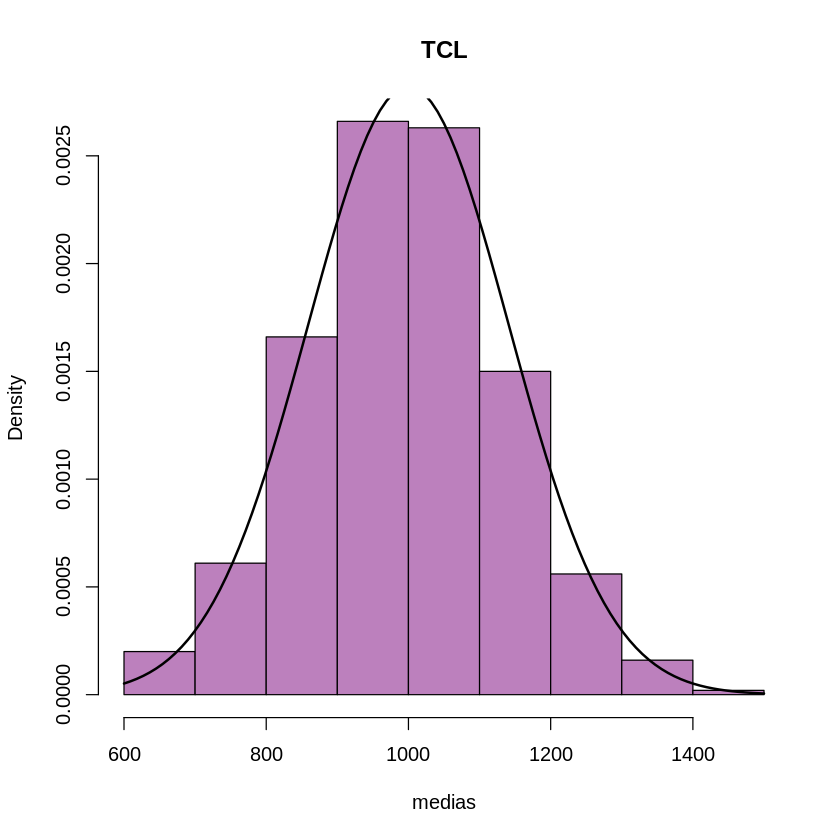

In [ ]:
medias <- replicate(1000, mean(rexp(50,1/1000)))

hist(medias, probability=TRUE, col="#bc80bd",
     main="TCL")
curve(dnorm(x,1000,1000/sqrt(50)), add=TRUE,lwd=2)

# **Exemplo 11: Erro Padrão vs n**

**Enunciado:**
Analise como o erro padrão varia com o tamanho da amostra.

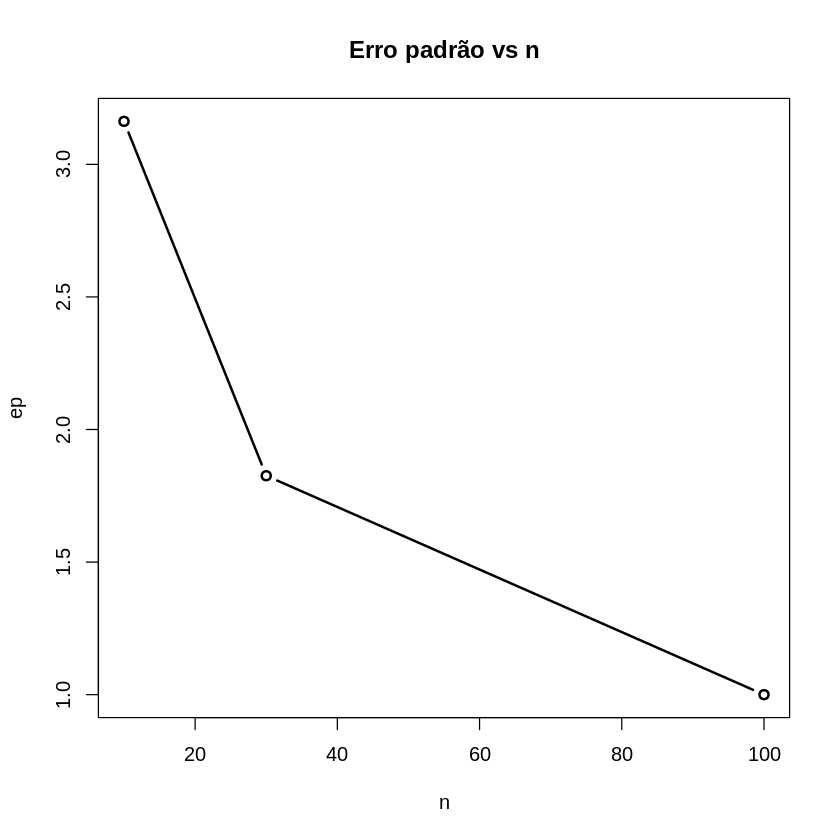

In [ ]:
n <- c(10,30,100)
ep <- 10/sqrt(n)

plot(n,ep,type="b",lwd=2,
     main="Erro padrão vs n")

# **Exemplo 12: Normal Aproximada**

**Enunciado:**
Visualize uma distribuição normal aproximada para a média amostral.

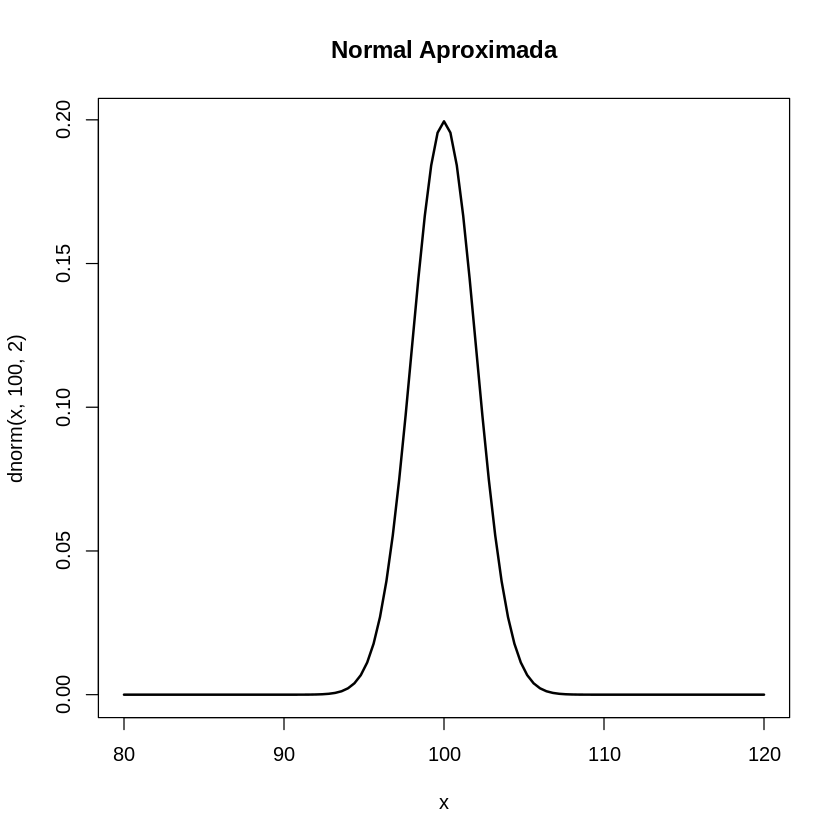

In [ ]:
curve(dnorm(x,100,2), from=80,to=120,
      lwd=2, main="Normal Aproximada")

# **Exemplo 13: Área de Probabilidade**

**Enunciado:**
Calcule graficamente P(x̄ < 168).

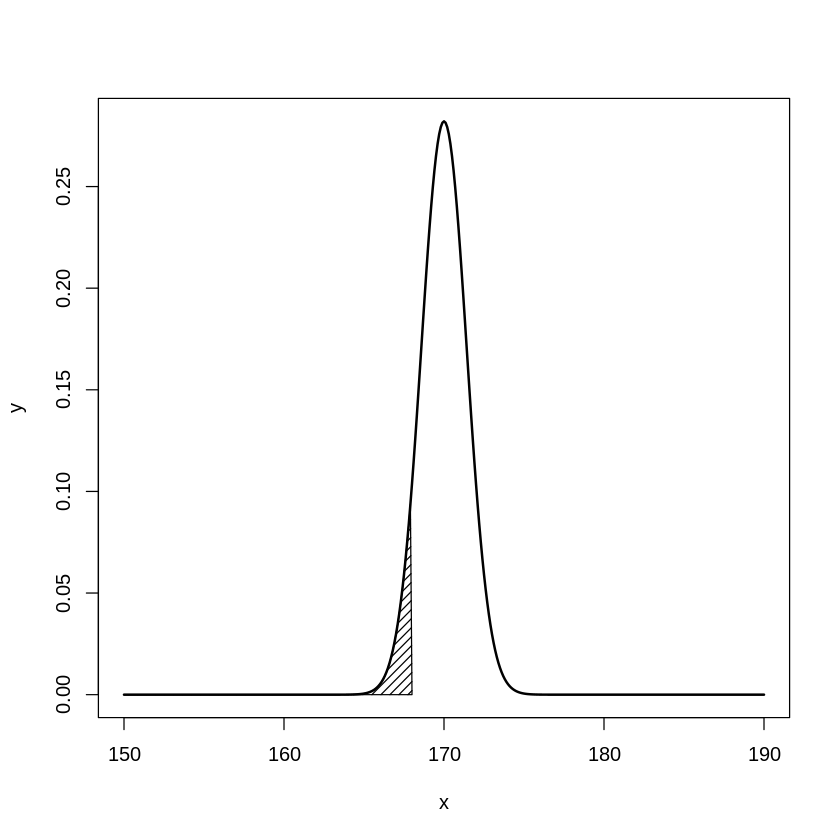

In [ ]:
x <- seq(150,190,0.1)
y <- dnorm(x,170,10/sqrt(50))

plot(x,y,type="l",lwd=2)
polygon(c(x[x<168],168),
        c(y[x<168],0), density=20)

# **Exemplo 14: Distribuição Z**

**Enunciado:**
Represente graficamente a distribuição normal padrão.

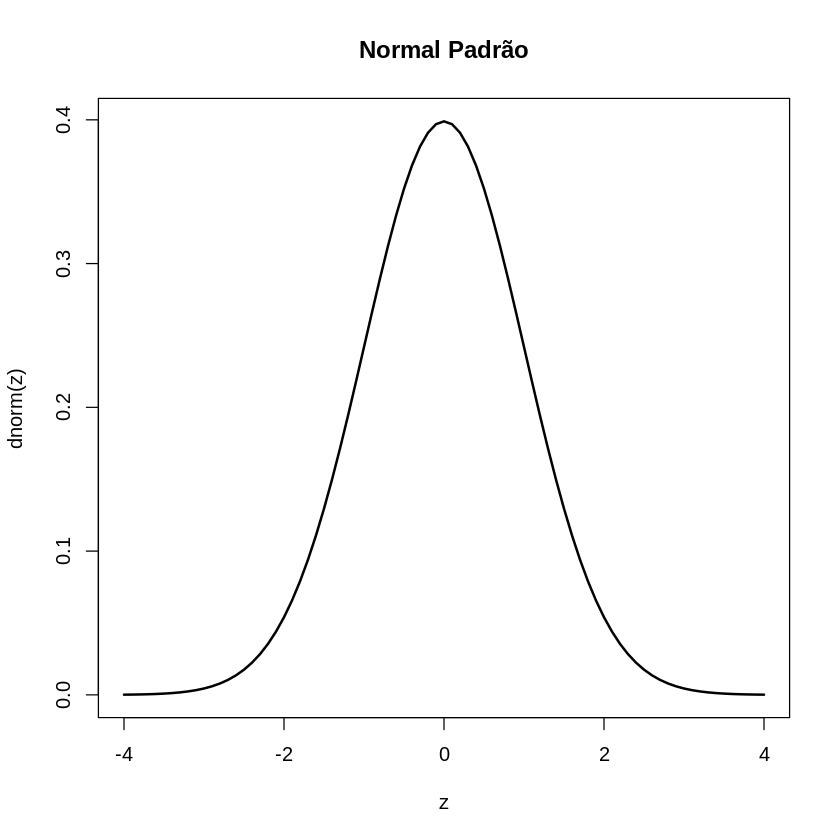

In [ ]:
z <- seq(-4,4,0.1)
plot(z,dnorm(z),type="l",lwd=2,
     main="Normal Padrão")

# **Exemplo 15: Variável Bernoulli**

**Enunciado:**
Simule uma variável Bernoulli com p=0.6 e visualize sua distribuição.

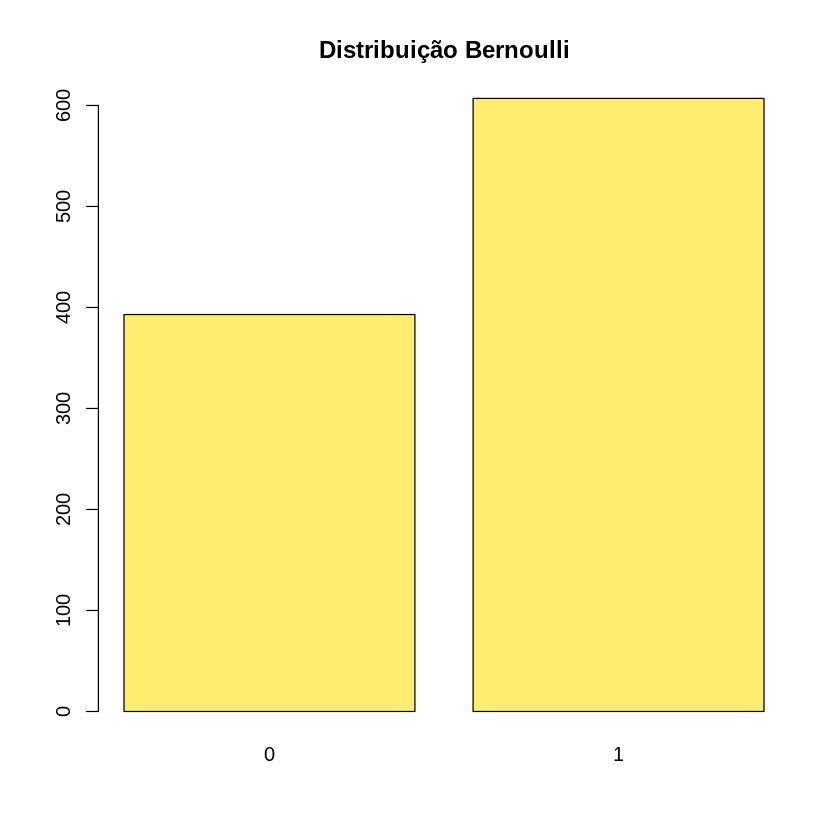

In [ ]:
dados <- rbinom(1000,1,0.6)

barplot(table(dados),
        col="#ffed6f",
        main="Distribuição Bernoulli")

# **Exemplo 16: Distribuição de p̂**

**Enunciado:**
Simule a distribuição da proporção amostral para n=50.

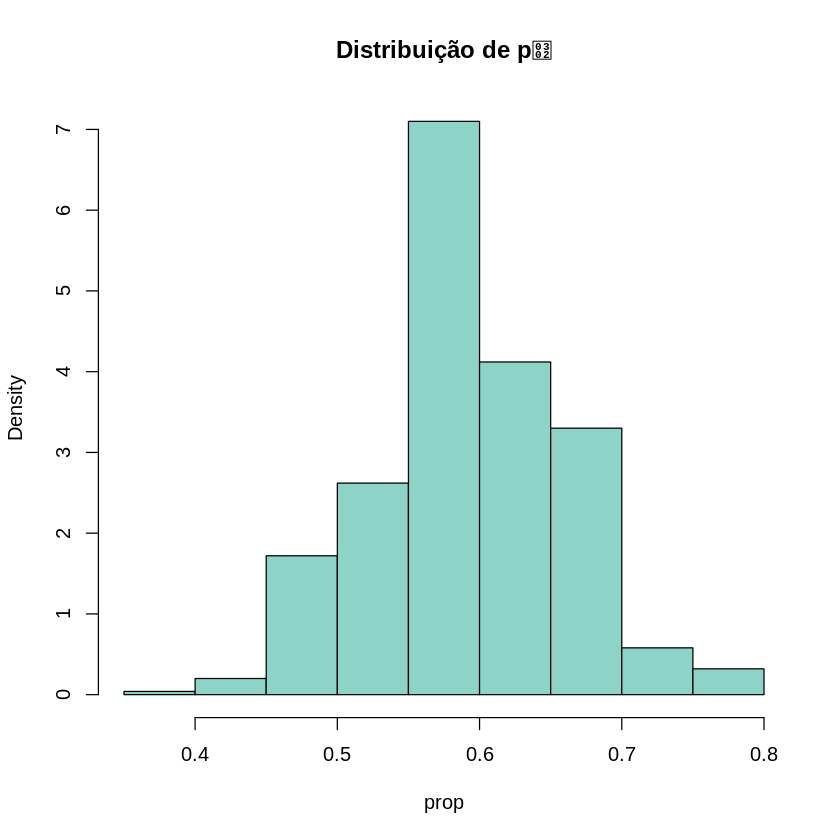

In [ ]:
prop <- replicate(1000, mean(rbinom(50,1,0.6)))

hist(prop, probability=TRUE,
     col="#8dd3c7",
     main="Distribuição de p̂")

# **Exemplo 17: Aproximação Normal**

**Enunciado:**
Compare a distribuição simulada de p̂ com a normal teórica.

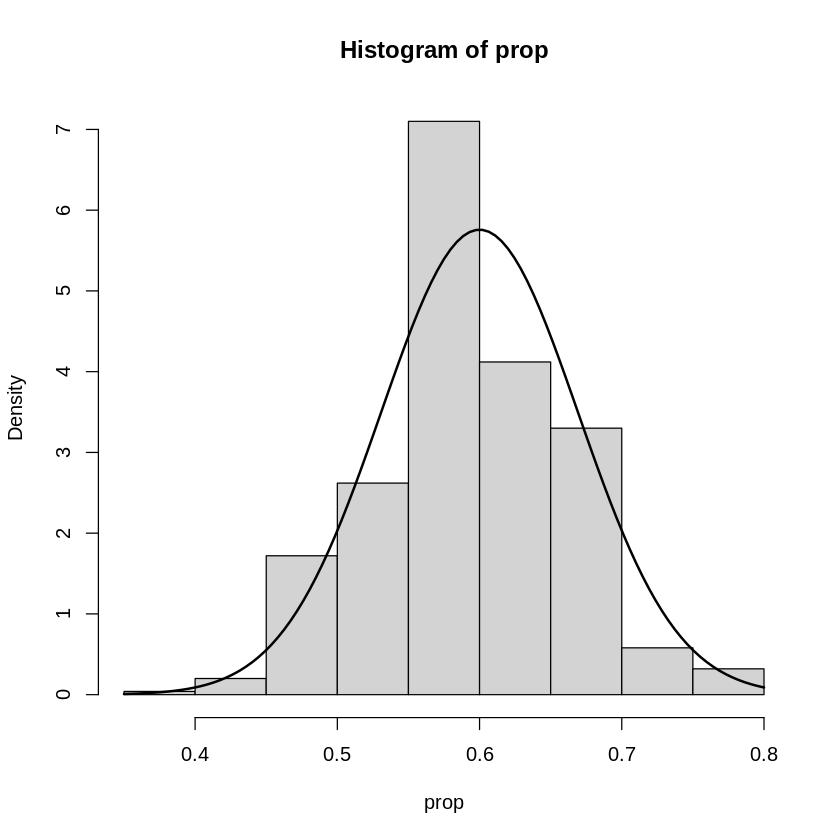

In [ ]:
hist(prop, probability=TRUE)
curve(dnorm(x,0.6,sqrt(0.6*0.4/50)),
      add=TRUE,lwd=2)

# **Exemplo 18: Intervalo de Confiança para Proporção**

**Enunciado:**
Uma pesquisa eleitoral entrevistou n = 50 pessoas, das quais 30 declararam apoio a um candidato (p̂ = 0.6).
Construa um intervalo de confiança de 95% para a proporção populacional p e represente graficamente:

a distribuição aproximada de p̂
a região correspondente ao intervalo de confiança

[1] 0.4642097 0.7357903


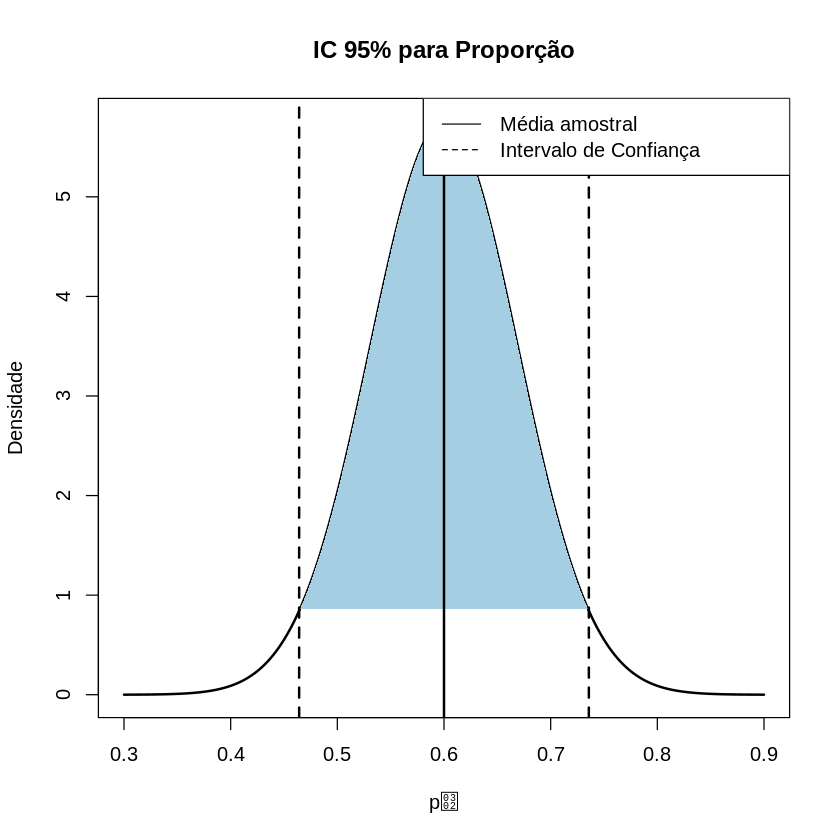

In [ ]:
# Dados
n <- 50
p_hat <- 30/50
z <- qnorm(0.975)

# Erro padrão
ep <- sqrt(p_hat*(1-p_hat)/n)

# Intervalo de confiança
erro <- z * ep
ic_inf <- p_hat - erro
ic_sup <- p_hat + erro

print(c(ic_inf, ic_sup))

# Curva normal aproximada
x <- seq(0.3, 0.9, 0.001)
y <- dnorm(x, mean=p_hat, sd=ep)

plot(x, y, type="l", lwd=2,
     main="IC 95% para Proporção",
     xlab="p̂", ylab="Densidade")

# Área do intervalo
idx <- x >= ic_inf & x <= ic_sup
polygon(x[idx], y[idx], col="#a6cee3", border=NA)

# Linhas
abline(v=p_hat, lwd=2)
abline(v=c(ic_inf, ic_sup), lwd=2, lty=2)

legend("topright",
       legend=c("Média amostral","Intervalo de Confiança"),
       lty=c(1,2))

# **Exemplo 19: Valor-P**

**Enunciado:**
Um fabricante afirma que a proporção de defeitos é p = 0.10.
Em uma amostra de n = 100, observou-se p̂ = 0.15.

Teste a hipótese:

*   $𝐻_{0}:𝑝=0.10$
*   $𝐻_{1}:𝑝>0.10$

Calcule o valor-P e represente graficamente a área correspondente na distribuição normal.

[1] 1.666667
[1] 0.04779035


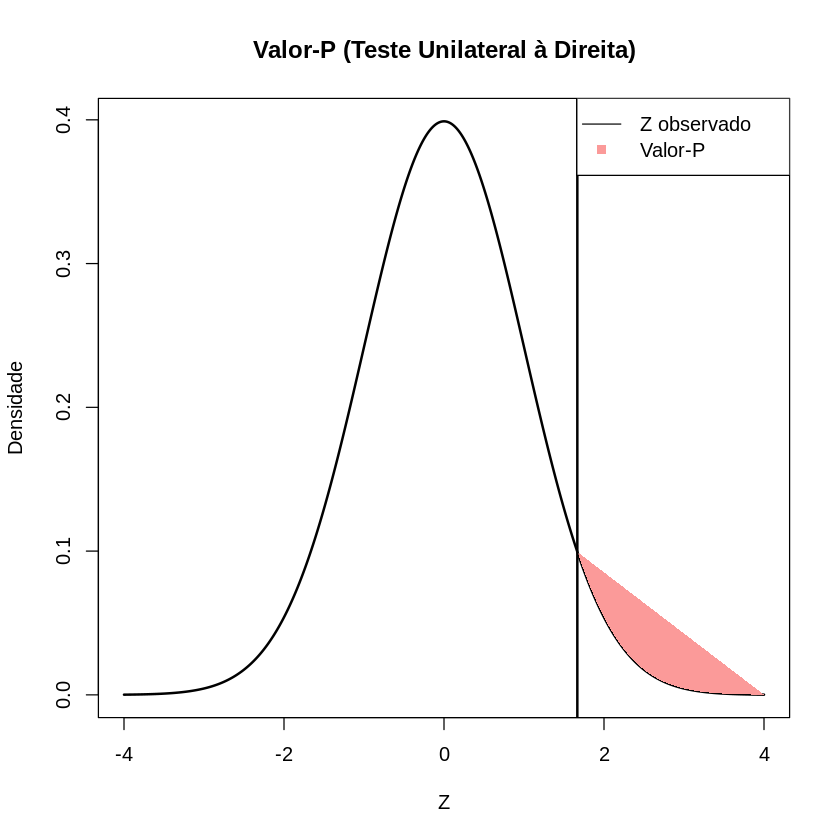

In [ ]:
# Dados
p0 <- 0.10
n <- 100
p_hat <- 0.15

# Erro padrão sob H0
ep <- sqrt(p0*(1-p0)/n)

# Estatística Z
z_obs <- (p_hat - p0)/ep
valor_p <- 1 - pnorm(z_obs)

print(z_obs)
print(valor_p)

# Gráfico
z <- seq(-4,4,0.001)
y <- dnorm(z)

plot(z, y, type="l", lwd=2,
     main="Valor-P (Teste Unilateral à Direita)",
     xlab="Z", ylab="Densidade")

# Área do valor-P
idx <- z >= z_obs
polygon(z[idx], y[idx], col="#fb9a99", border=NA)

abline(v=z_obs, lwd=2)

legend("topright",
       legend=c("Z observado","Valor-P"),
       lty=c(1,NA), pch=c(NA,15),
       col=c("black","#fb9a99"))

# **Exemplo 20: Binomial vs Normal**

**Enunciado:**


Uma moeda justa (p = 0.5) é lançada n = 20 vezes.

Calcule a probabilidade de obter entre 8 e 12 caras:


**1.**   Usando a **distribuição binomial exata**
**2.**   Usando a **aproximação normal com correção de continuidade**

Compare os resultados e represente graficamente ambas as distribuições.

[1] 0.736824
[1] 0.7364475


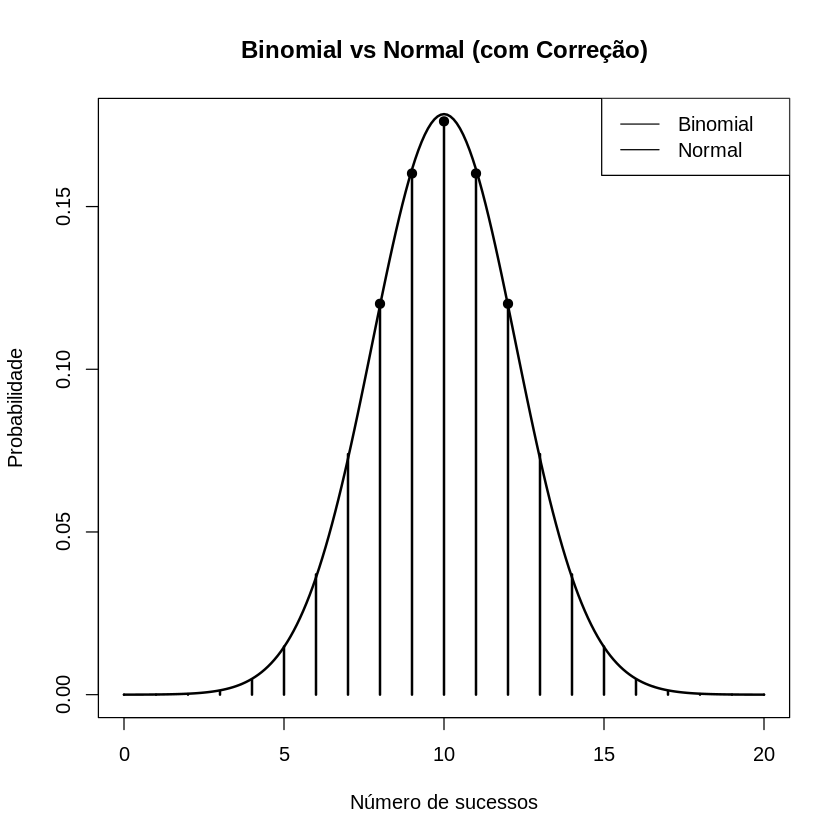

In [ ]:
# Parâmetros
n <- 20
p <- 0.5

# Probabilidade exata
prob_exata <- sum(dbinom(8:12, size=n, prob=p))

# Aproximação normal
mu <- n*p
sigma <- sqrt(n*p*(1-p))

# Correção de continuidade
prob_aprox <- pnorm(12.5, mu, sigma) - pnorm(7.5, mu, sigma)

print(prob_exata)
print(prob_aprox)

# Gráfico comparativo
x <- 0:20

# Binomial
plot(x, dbinom(x,n,p), type="h", lwd=2,
     main="Binomial vs Normal (com Correção)",
     xlab="Número de sucessos", ylab="Probabilidade")

# Normal contínua
xx <- seq(0,20,0.1)
lines(xx, dnorm(xx, mu, sigma), lwd=2)

# Destaque do intervalo [8,12]
for(i in 8:12){
  points(i, dbinom(i,n,p), pch=19)
}

legend("topright",
       legend=c("Binomial","Normal"),
       lty=c(1,1))

In [ ]:
# Configuração do ambiente e semente para reprodutibilidade
set.seed(42)

# 1. Simulação
brilho_estelar <- rnorm(n = 1000, mean = 15.5, sd = 0.8)

# 2. Visualização (Exemplo com ggplot2)
library(ggplot2)
df <- data.frame(brilho = brilho_estelar)
ggplot(df, aes(x = brilho)) +
  geom_histogram(aes(y = ..density..), binwidth = 0.2, fill = "royalblue", alpha = 0.7) +
  stat_function(fun = dnorm, args = list(mean = mean(df$brilho), sd = sd(df$brilho)), color = "red") +
  theme_minimal() +
  labs(title = "Distribuição do Brilho Estelar Observado", x = "Magnitude", y = "Densidade")

# 3. Inferência (Intervalo de Confiança)
media_amostral <- mean(brilho_estelar)
erro_padrao <- sd(brilho_estelar) / sqrt(1000)
ic_95 <- c(media_amostral - 1.96 * erro_padrao, media_amostral + 1.96 * erro_padrao)
print(ic_95)